# <ins>Retail Data Analytics</ins>

**Background**
This project will analyse retail data. The aims are first to load, clean, and tranform the data. Second, to extract meaningful information about sales around prominent holidays. Third, to display the insights in easily understandable and actionable ways.

**Data**
Data comes from 45 stores, located in different regions, each with multiple departments. Granularity is weeks, of which there are special ones designated as <ins>*markdown periods*</ins> around prominent holidays, which are weighted <ins>*5x higher*</ins> than normal ones.

3 datasets
1. Stores
2. Features
    - Store - the store number
    - Date - the week
    - Temperature - average temperature in the region
    - Fuel_Price - cost of fuel in the region
    - MarkDown1-5 - anonymized data related to promotional markdowns. <ins>*MarkDown data is only available after Nov 2011, and is not available for all stores all the time. Any missing value is marked with an NA*</ins>
    - CPI - the consumer price index
    - Unemployment - the unemployment rate
    - IsHoliday - whether the week is a special holiday week
3. Sales:
    - Store - the store number
    - Dept - the department number
    - Date - the week
    - Weekly_Sales -  sales for the given department in the given store
    - IsHoliday - whether the week is a special holiday week


**Project Layout**
1. Preliminary data exploration
2. Data cleaning
3. Data transformation and feature engineering
4. Exploratory data analysis + visualisations



In [259]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler


# 1. Preliminary data exploration

## Load and Combine

In [260]:
# load data
stores = pd.read_csv('stores data-set.csv')
sales = pd.read_csv('sales data-set.csv')
features = pd.read_csv('Features data set.csv')

In [261]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [262]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [263]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [264]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [265]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [266]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [267]:
# work out the 'hierarchy' of the dataframes based on their granularity
print(f"Stores have unique store numbers? - {stores['Store'].nunique() == stores.shape[0]}")
print(f"Features has unique store numbers - date combinations? - {features[['Store', 'Date']].duplicated().sum() == 0}")
print(f"Sales has unique store numbers - department - date combinations? - {sales[['Store','Dept', 'Date']].duplicated().sum() == 0}")

Stores have unique store numbers? - True
Features has unique store numbers - date combinations? - True
Sales has unique store numbers - department - date combinations? - True


The above suggests that <ins>Sales</ins> has the highest granularity (unique values for each store + department + date), followed by Features and Stores => Sales is the main dataframe, Features will be merged into it, followed by Stores at the end.

In [268]:
# merge the dataframes
df = sales.merge(features, how='left', on=['Store', 'Date']).merge(stores, how='left', on='Store')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [269]:
# col 'IsHoliday' appeared in both Sales and Features, it can be used to check the quality of the merge
# values not matching would suggest a merge issue
(df['IsHoliday_x'] == df['IsHoliday_y']).to_frame().iloc[:].value_counts()


0   
True    421570
Name: count, dtype: int64

In [270]:
df.shape

(421570, 17)

All values are matching! Whilst this does **NOT** guarantee the lack of issues, it does at least disprove that there are any obvious mismatches.

## Quality check

In [272]:
# check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

Most columns are of the correct type. Convert Data to datetime format, and round CPI and Unemployment.

In [273]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [274]:
# check missing values
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

Only the MarkDown columns have missing values (noted already by the dataset providers). However, not all missing values are easily interpreatable by pandas as NaNs. Some can be values such as 0, or "don't know", which require a different method to identify.

In [275]:
# check for additional nans together with erroneous values check
invalid = {
    "invalid_store": int((df['Store']<=0).sum()),
    "invalid_dept": int((df['Dept']<=0).sum()),
    "negative_sales": int((df['Weekly_Sales']<=0).sum()),
    "temp_outside_range": int(((df['Temperature'] < -40) | (df['Temperature'] > 122)).sum()), # temp in Fahrenheit
    "negative_fuel_price": int((df['Fuel_Price']<=0).sum()),
    "negative_mkd1": int((df['MarkDown1']<=0).sum()),
    "negative_mkd2": int((df['MarkDown2']<=0).sum()),
    "negative_mkd3": int((df['MarkDown3']<=0).sum()),
    "negative_mkd4": int((df['MarkDown4']<=0).sum()),
    "negative_mkd5": int((df['MarkDown5']<=0).sum()),
    "negative_unemployment_rate": int((df['Unemployment']<=0).sum()),
    "negative_store_size": int((df['Size']<=0).sum()),
}
for key,value in invalid.items():
    print(f"{key}: {value}")
    print(30*'*')


invalid_store: 0
******************************
invalid_dept: 0
******************************
negative_sales: 1358
******************************
temp_outside_range: 0
******************************
negative_fuel_price: 0
******************************
negative_mkd1: 0
******************************
negative_mkd2: 1518
******************************
negative_mkd3: 324
******************************
negative_mkd4: 0
******************************
negative_mkd5: 0
******************************
negative_unemployment_rate: 0
******************************
negative_store_size: 0
******************************


Some erroneous values in Weekly_Sales, MarkDown 2 and 3. No indication of additional missing values though.

In [276]:
# quick check for outliers
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,421570.0,22.200546,12.785297,1.000,11.000000,22.00000,33.000000,45.000000
Dept,421570.0,44.260317,30.492054,1.000,18.000000,37.00000,74.000000,99.000000
Weekly_Sales,421570.0,15981.258123,22711.183519,-4988.940,2079.650000,7612.03000,20205.852500,693099.360000
Temperature,421570.0,60.090059,18.447931,-2.060,46.680000,62.09000,74.280000,100.140000
Fuel_Price,421570.0,3.361027,0.458515,2.472,2.933000,3.45200,3.738000,4.468000
MarkDown1,150681.0,7246.420196,8291.221345,0.270,2240.270000,5347.45000,9210.900000,88646.760000
MarkDown2,111248.0,3334.628621,9475.357325,-265.760,41.600000,192.00000,1926.940000,104519.540000
MarkDown3,137091.0,1439.421384,9623.078290,-29.100,5.080000,24.60000,103.990000,141630.610000
MarkDown4,134967.0,3383.168256,6292.384031,0.220,504.220000,1481.31000,3595.040000,67474.850000
MarkDown5,151432.0,4628.975079,5962.887455,135.160,1878.440000,3359.45000,5563.800000,108519.280000


Judging the 'jump' from the 75th percentile to the MAX, it can be concluded that the following columns may have outliers:
- Weekly_Sales: 20k (75th) to 693k (max)
- All 5 MarkDowns have massive differences between 75th and max

In [277]:
# check for imbalances in categorical columns
cat_cols = ['Dept', 'IsHoliday_x', 'Type']
for cat in cat_cols:
    print(df[cat].value_counts())
    print(30*'*')

Dept
1     6435
16    6435
92    6435
38    6435
40    6435
      ... 
78     235
77     150
65     143
39      16
43      12
Name: count, Length: 81, dtype: int64
******************************
IsHoliday_x
False    391909
True      29661
Name: count, dtype: int64
******************************
Type
A    215478
B    163495
C     42597
Name: count, dtype: int64
******************************


In Dept, there are 99 categories, very imbalanced. As expected, there are far more non Holidays. Type C is significantly smaller than the other categories.

<ins>**To do**</ins>
1. Drop IsHoliday_y and rename IsHoliday_x
2. Convert Date to datetime format + check for erroneous values
3. Round CPI, Fuel price and Unemployment to 2 decimals
4. Find a way to account for nans in Markdowns, **DON'T** input 0 values (would be incorrect)
5. Fix erroneous negative values in Weekly_Sales, MarkDown 2 & 3
6. Check for outliers in Weekly_Sales and all 5 MarkDowns
7. Consider binning col Dept (see Data Insights)


<ins>*Data Insights*</ins>
1. Type is imbalanced, but unlikely to be an issue.
2. Massive imbalance between Holidays and non Holidays, leave as is
3. Col Dept can be used for a dual purpose: as part of an ID, if current granularity is kept; or as a store size feature if granularity is raise to store level.
4. MarkDown columns represent anonymised quantitative features most likely (though unconfirmed by dataset source) show the intensity of promotional activities. The scale of the 5 cols varies significantly, recommend normalising them to facilitates comparison.
5. MarkDown outliers need **special treatment**: spikes around Holidays are to be expected, spikes outside Holidays may be flagged for outlier elimination.

# 2. Data cleaning

In [278]:
# drop IsHoliday_y and rename IsHoliday_x
df.drop('IsHoliday_y', axis = 1, inplace = True)
df.rename(columns={'IsHoliday_x': 'Holiday'}, inplace = True) 

In [279]:
# convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')


In [280]:
# check the values
for year in [2010, 2011, 2012]:
    for store in [1, 2, 3]:
        for dept in [1, 2, 3]:
            print(f"Year {year}, Store {store}, {dept} - {df[df['Date'].dt.year == year].query(f"Store == {store} & Dept == {dept}").shape[0]} entries")

Year 2010, Store 1, 1 - 48 entries
Year 2010, Store 1, 2 - 48 entries
Year 2010, Store 1, 3 - 48 entries
Year 2010, Store 2, 1 - 48 entries
Year 2010, Store 2, 2 - 48 entries
Year 2010, Store 2, 3 - 48 entries
Year 2010, Store 3, 1 - 48 entries
Year 2010, Store 3, 2 - 48 entries
Year 2010, Store 3, 3 - 48 entries
Year 2011, Store 1, 1 - 52 entries
Year 2011, Store 1, 2 - 52 entries
Year 2011, Store 1, 3 - 52 entries
Year 2011, Store 2, 1 - 52 entries
Year 2011, Store 2, 2 - 52 entries
Year 2011, Store 2, 3 - 52 entries
Year 2011, Store 3, 1 - 52 entries
Year 2011, Store 3, 2 - 52 entries
Year 2011, Store 3, 3 - 52 entries
Year 2012, Store 1, 1 - 43 entries
Year 2012, Store 1, 2 - 43 entries
Year 2012, Store 1, 3 - 43 entries
Year 2012, Store 2, 1 - 43 entries
Year 2012, Store 2, 2 - 43 entries
Year 2012, Store 2, 3 - 43 entries
Year 2012, Store 3, 1 - 43 entries
Year 2012, Store 3, 2 - 43 entries
Year 2012, Store 3, 3 - 43 entries


Not all years are complete, but the pattern seems to be consistent across several stores and departments.

In [281]:
# round CPI, Fuel price, and Unemployment
for col in ['CPI', 'Fuel_Price', 'Unemployment']:
    df[col] = round(df[col], 2)

## Erroneous values

### Weekly_Sales

In [282]:
# explore negative values, look for patterns
negatives = df.query("Weekly_Sales < 0").groupby(['Store', 'Dept'])['Weekly_Sales'].count().to_frame().reset_index()
negatives

,Store,Dept,Weekly_Sales
0,1,6,1
1,1,18,1
2,1,47,9
3,1,48,1
4,1,54,3
...,...,...,...
371,45,47,2
372,45,49,8
373,45,54,5
374,45,77,1


Inspecting the above dataframe using <ins>Data Wrangler</ins> revealed:
1. Vast majority of entries only have <10 negative values, likely an honest mistake => can be replaced with an adequate value
2. Several have as many as >20, which may indicate a systemic issue.

In [283]:
# explore example of Store + Department with over 20 negatives
df.query("Store == 35 & Dept == 80").describe().T

,count,mean,min,25%,50%,75%,max,std
Store,134.0,35.0,35.0,35.0,35.0,35.0,35.0,0.0
Dept,134.0,80.0,80.0,80.0,80.0,80.0,80.0,0.0
Date,134,2011-07-11 14:30:26.865671680,2010-02-05 00:00:00,2010-11-27 18:00:00,2011-07-18 12:00:00,2012-03-07 06:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,134.0,51.00694,-454.42,6.1225,34.96,103.59,432.64,105.735641
Temperature,134.0,57.408284,23.64,43.81,58.98,72.9175,82.69,16.445417
Fuel_Price,134.0,3.452985,2.7,3.0425,3.57,3.8175,4.07,0.434394
MarkDown1,51.0,10800.349804,318.61,4840.655,6982.1,12383.06,62567.6,10845.276634
MarkDown2,29.0,3878.667931,-7.6,42.64,344.55,4413.52,34766.99,7112.818084
MarkDown3,48.0,1609.270833,0.15,5.2425,11.255,86.535,58563.24,8548.565758
MarkDown4,51.0,4279.594118,20.97,943.0,1976.76,4614.32,40201.38,7092.271893


This department is indeed very poorly performing. However, the dataset description does not explicitly state that sales can be negative, therefore, it cannot be assumed. 

<ins>NOTE</ins>: in the case of store 34, dept 80, there is magnitude symmetry between the positives and negatives, suggesting that the '-' sign could have been erroneously put there.

<ins>ACTION</ins>: when there is magnitude symmetry, multiply negative values by -1

In [284]:
def fix_negative_sales(df):
    """
    This function takes the dataframe and converts negative sales values after the following logic:
        if the value is lower than the max value within its specific store department + 1 standard deviation, 
            then multiply by -1, else leave as is 
    """
    df = df.copy()
    grouped = df.groupby(['Store', 'Dept'])['Weekly_Sales']
    stats = grouped.agg(['max', 'std']).rename(columns={'max':'max_val','std':'std_val'})
    merged = df.merge(stats, on=['Store','Dept'], how='left')
    mask = (merged['Weekly_Sales'] < 0) & (merged['Weekly_Sales'].abs() <= (merged['max_val'] + merged['std_val']))
    merged.loc[mask, 'Weekly_Sales'] *= -1
    return merged.drop(columns=['max_val','std_val'])

In [285]:
# apply logic to df
df = fix_negative_sales(df)

# recheck negatives
negatives = df.query("Weekly_Sales < 0").groupby(['Store', 'Dept'])['Weekly_Sales'].count().to_frame().reset_index()
negatives

,Store,Dept,Weekly_Sales
0,1,47,2
1,6,47,1
2,9,80,1
3,11,47,1
4,14,47,1
5,15,37,1
6,16,47,1
7,18,96,1
8,19,19,2
9,22,48,1


The remaining ones will be replaced with the median of the store department.

In [286]:
def impute_remaining_negatives(df, target_col):
    """
    This function replaces the remaining negatives with the medians of their respective store department.
    NOTE: the logic does not work for groups (store+dept) where all entries are negative, those will be dropped altogether
    """
    df = df.copy()
    
    # identify groups where all sales are negative
    all_negative_groups = (
        df.groupby(['Store','Dept'])['Weekly_Sales']
        .transform(lambda x: (x < 0).all()))
    # drop isolated negatives and all-negative groups
    counts = df.groupby(['Store','Dept'])['Weekly_Sales'].transform('count')
    drop_mask = ((df['Weekly_Sales'] < 0) & (counts == 1)) | all_negative_groups
    df = df[~drop_mask].copy()

    # compute median per store–department using only nonnegative values
    medians = (
        df[df[target_col] >= 0]
        .groupby(['Store', 'Dept'])[target_col]
        .median()
        .rename('median_val')
    )
    df = df.merge(medians, on=['Store', 'Dept'], how='left')
    # replace remaining negatives
    df.loc[df[target_col] < 0, target_col] = df.loc[df[target_col] < 0, 'median_val']
    return df.drop(columns=['median_val'])

In [287]:
# apply logic to df
df = impute_remaining_negatives(df, 'Weekly_Sales')

# recheck negatives
negatives = df.query("Weekly_Sales < 0").groupby(['Store', 'Dept'])['Weekly_Sales'].count().to_frame().reset_index()
negatives

,Store,Dept,Weekly_Sales


### MarkDowns

In [288]:
# explore negative values, look for patterns
for mk in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']:
    print(mk, df.query(f"{mk} < 0").groupby(['Store', 'Dept'])[mk].count().to_frame().reset_index().shape[0])


MarkDown1 0
MarkDown2 1042
MarkDown3 257
MarkDown4 0
MarkDown5 0


In [289]:
# explore negative values, look for patterns
negatives_mk2 = df.query("MarkDown2 < 0").groupby(['Store', 'Dept'])['MarkDown2'].count().to_frame().reset_index()
negatives_mk2

,Store,Dept,MarkDown2
0,4,1,1
1,4,2,1
2,4,3,1
3,4,4,1
4,4,5,1
...,...,...,...
1037,41,95,2
1038,41,96,2
1039,41,97,2
1040,41,98,2


In [290]:
# explore negative values, look for patterns
negatives_mk3 = df.query("MarkDown3 < 0").groupby(['Store', 'Dept'])['MarkDown3'].count().to_frame().reset_index()
negatives_mk3

,Store,Dept,MarkDown3
0,28,1,1
1,28,2,1
2,28,3,1
3,28,4,1
4,28,5,1
...,...,...,...
252,39,94,1
253,39,95,1
254,39,96,1
255,39,97,1


MK 2 and 3 have negative values, but nearly all are 1 per store department.

<ins>ACTION</ins>: implement replacement with median.

In [291]:
# convert negative values
for mk in ['MarkDown2','MarkDown3']:
    df = impute_remaining_negatives(df, mk)
    

In [292]:
# recheck 
for mk in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']:
    print(mk, df.query(f"{mk} < 0").groupby(['Store', 'Dept'])[mk].count().to_frame().reset_index().shape[0])


MarkDown1 0
MarkDown2 0
MarkDown3 0
MarkDown4 0
MarkDown5 0


## Outliers

### Weekly_Sales

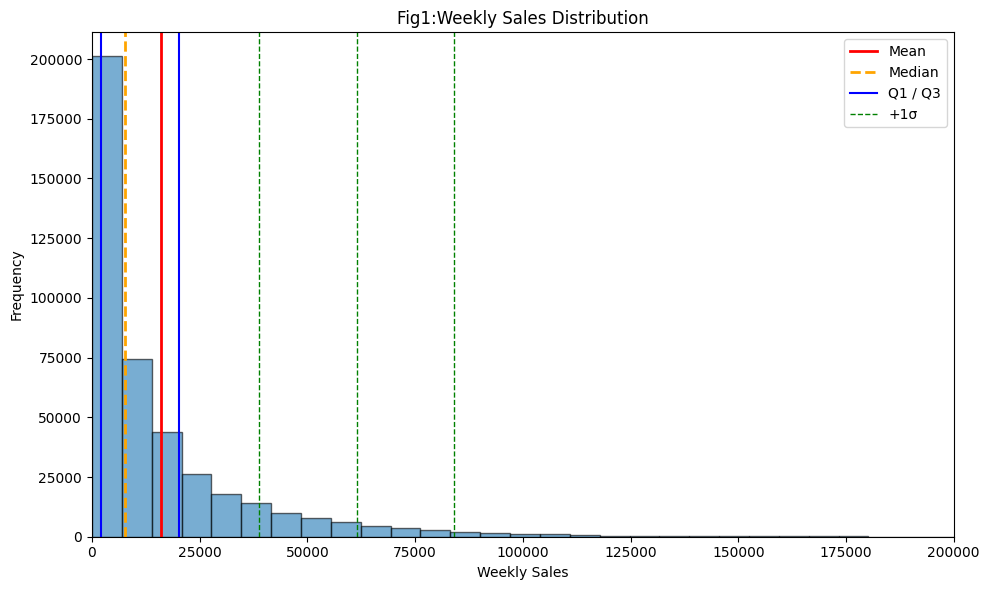

In [293]:
# visualise the distrubtion of Weekly_Sale
data = df['Weekly_Sales'].dropna()
mean = data.mean()
median = data.median()
q1, q3 = np.percentile(data, [25, 75])
std = data.std()

plt.figure(figsize=(10,6))
plt.hist(data, bins=100, alpha=0.6, edgecolor='black')
plt.xlim(0, 200000)

# mean
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label='Mean')
# median
plt.axvline(median, color='orange', linestyle='--', linewidth=2, label='Median')
# IQR
plt.axvline(q1, color='blue', linestyle='-', linewidth=1.5, label='Q1 / Q3')
plt.axvline(q3, color='blue', linestyle='-', linewidth=1.5)

# standard deviations
for i in [1, 2, 3]:
    plt.axvline(mean + i*std, color='green', linestyle='--', linewidth=1, label=f'+{i}σ' if i==1 else None)
    plt.axvline(mean - i*std, color='green', linestyle='--', linewidth=1)

plt.title('Fig1:Weekly Sales Distribution')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Look like an <ins>**Exponential Distribution**</ins> curve.

<ins>Problem</ins>
As the 1.5*IQR method assumes near-symmetric distribution (i.e. normal/Gaussian distribution), as this assumption is violated by the Exponential distribution, using it here can cause excessive tail trimming (on the left side) and result in information loss.

<ins>Solution</ins>
Use a **Quantile-based capping**: this only trims past a specified quantile, replacing all values beyond that point with the respective boundary. The advantages being that rank order and shape are preserved, whilst still eliminating the most extreme values that could damage the analysis the most.

NOTE: the equivalent on the lower side will be clipped as well to maintain simmetry.



In [294]:
def quantile_cap(df, col='Weekly_Sales', lower_q=0.01, upper_q=0.99):
    """
    This function clips the end of the distribution.
    """
    df = df.copy()
    lower, upper = df[col].quantile([lower_q, upper_q])
    df[col] = np.clip(df[col], lower, upper)
    return df

In [295]:
# apply quantile capping
df = quantile_cap(df)

In [296]:
df['Weekly_Sales'].describe().T

count    421561.000000
mean      15655.051164
std       20781.673044
min           6.000000
25%        2079.910000
50%        7612.580000
75%       20206.190000
max      106480.360000
Name: Weekly_Sales, dtype: float64

### MarkDowns

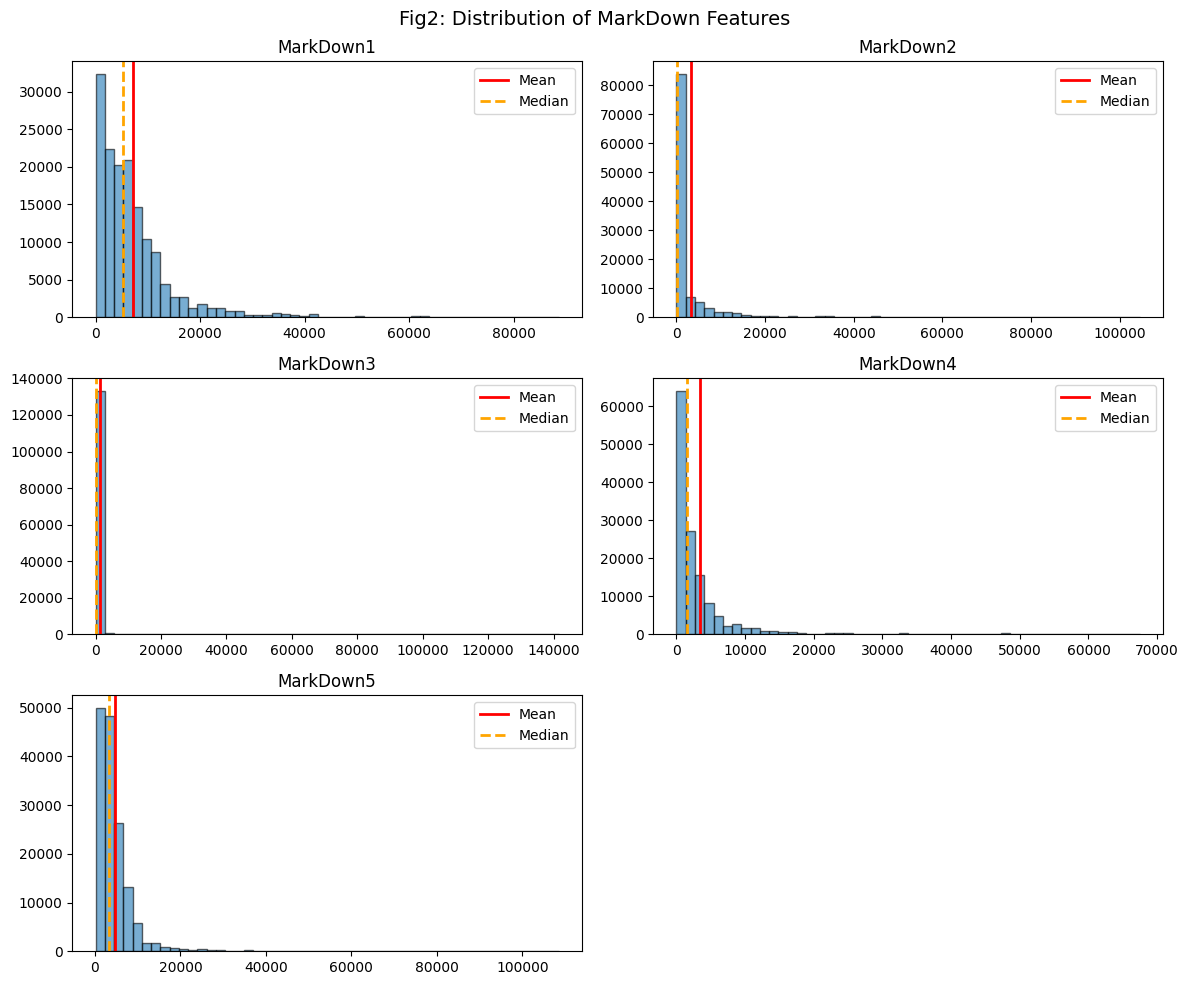

In [297]:
# visualise the distribution of the MarkDown cols
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
markdown_cols = [f'MarkDown{i}' for i in range(1, 6)]

for i, col in enumerate(markdown_cols):
    ax = axes[i]
    data = df[col].dropna()
    mean = data.mean()
    median = data.median()

    ax.hist(data, bins=50, alpha=0.6, edgecolor='black')
    ax.axvline(mean, color='red', linestyle='-', linewidth=2, label='Mean')
    ax.axvline(median, color='orange', linestyle='--', linewidth=2, label='Median')
    ax.set_title(col)
    ax.legend()

# remove unused last subplot (6th)
fig.delaxes(axes[-1])

fig.suptitle('Fig2: Distribution of MarkDown Features', fontsize=14)
plt.tight_layout()
plt.show()

As these also seem to be Exponential distributions, Quantile capping will be used.

In [298]:
for mk in ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']:
    df = quantile_cap(df, mk)

In [299]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].describe().T

,count,mean,std,min,25%,50%,75%,max
MarkDown1,150675.0,7101.185994,7421.420500,17.76,2240.27,5347.45,9210.90,41524.03
MarkDown2,111247.0,3148.338582,8058.468259,0.24,45.00,200.82,1926.94,50366.60
MarkDown3,137087.0,1232.975126,7696.978132,0.15,5.16,24.82,103.99,63143.29
MarkDown4,134964.0,3266.765225,5486.647196,3.97,504.22,1481.31,3595.04,35785.26
MarkDown5,151426.0,4446.360948,4232.255157,351.97,1878.44,3359.45,5563.80,27754.23


## Save clean

In [300]:
df.to_csv('cleaned_data.csv', index=False)

# 3. Data transformation and feature engineering

## MarkDown cols Standardisation

The scale of these columns varies significantly, at the same time, the absolute values do not mean anything (unlike Weekly_Sale which represents actual sums of money).

<ins>ACTION</ins>:
Standardise all MarkDown columns to facilitate statistical comparison.

Use <ins>log transform</ins> deal with the skew (compress the exponential right tails and approximate a symmetric distribution), then use a <ins>Z-score</ins> to deal with the scale (centre and scale the values).

In [301]:
def normalize_markdowns(df):
    """
    Normalize the MarkDown columns using log transform followed by Z-score standardization.
    """
    df = df.copy()
    markdown_cols = [f'MarkDown{i}' for i in range(1, 6)]
    # log transform
    for col in markdown_cols:
        df[col] = np.log1p(df[col].clip(lower=0))  # log(1 + x), ensures nonnegative
    # z-score standardization
    scaler = StandardScaler()
    df[markdown_cols] = scaler.fit_transform(df[markdown_cols])

    return df

In [302]:
# apply function
df = normalize_markdowns(df)

In [303]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421561.0,22.200234,1.0,11.0,22.0,33.0,45.0,12.785177
Dept,421561.0,44.259977,1.0,18.0,37.0,74.0,99.0,30.492151
Date,421561,2011-06-18 08:23:59.928267008,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421561.0,15655.051164,6.0,2079.91,7612.58,20206.19,106480.36,20781.673044
Temperature,421561.0,60.089962,-2.06,46.68,62.09,74.28,100.14,18.447976
Fuel_Price,421561.0,3.361043,2.47,2.93,3.45,3.74,4.47,0.458595
MarkDown1,150675.0,0.0,-3.471393,-0.309069,0.265975,0.625435,1.620994,1.000003
MarkDown2,111247.0,0.0,-2.11747,-0.682792,-0.095691,0.800338,2.095804,1.000004
MarkDown3,137087.0,-0.0,-1.562365,-0.766266,-0.086496,0.578875,3.614354,1.000004
MarkDown4,134964.0,-0.0,-3.141045,-0.471656,0.150044,0.661925,1.989079,1.000004


## Feature engineering

In [304]:
# calculate holiday sales difference for each store department
grouped = df.groupby(['Store', 'Dept', 'Holiday'])['Weekly_Sales'].mean().unstack(fill_value=np.nan).rename(columns={
    False: 'NonHoliday_Mean', 
    True: 'Holiday_Mean'})
grouped['Holiday_Sales_diff'] = round(grouped['Holiday_Mean'] - grouped['NonHoliday_Mean'], 2)

# merge into main df
df = df.merge(grouped['Holiday_Sales_diff'].reset_index(), on=['Store', 'Dept'], how='left')

# 4. Exploratory data analysis + visualisations

## Descriptive Analysis

In [305]:
df.head()

,Store,Dept,Date,Weekly_Sales,Holiday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Holiday_Sales_diff
0,1,1,2010-02-05,24924.50,False,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,A,151315,3467.77
1,1,1,2010-02-12,46039.49,True,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,A,151315,3467.77
2,1,1,2010-02-19,41595.55,False,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,A,151315,3467.77
3,1,1,2010-02-26,19403.54,False,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,A,151315,3467.77
4,1,1,2010-03-05,21827.90,False,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,A,151315,3467.77


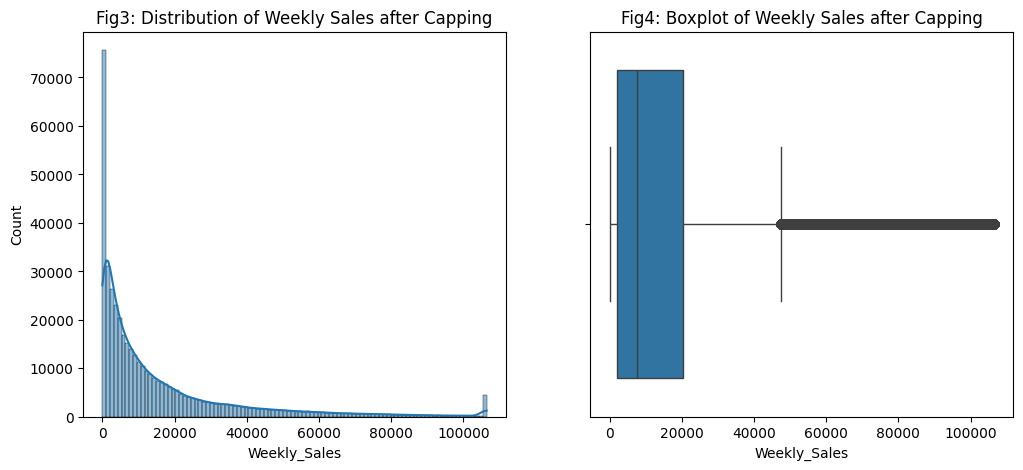

In [306]:
# check the distribution of the modified Weekly_Sales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['Weekly_Sales'], bins=100, ax=axes[0], kde=True);
axes[0].set_title('Fig3: Distribution of Weekly Sales after Capping');

sns.boxplot(x=df['Weekly_Sales'], ax=axes[1]);
axes[1].set_title('Fig4: Boxplot of Weekly Sales after Capping');

In [307]:
# view distribution as violin plot
fig = px.violin(df, y="Weekly_Sales")
fig.update_layout(title='Fig5:Weekly Sales Violin Plot')
fig.update_xaxes(title='Weekly Sales')
fig.update_yaxes(title='Frequency')
fig.show()


- After Quantile capping, Weekly_Sales maintains a strong exponential distribution.
- Extreme values are considered those roughly above 45k.
- There is now a increased density of values around 100k due to the capping.

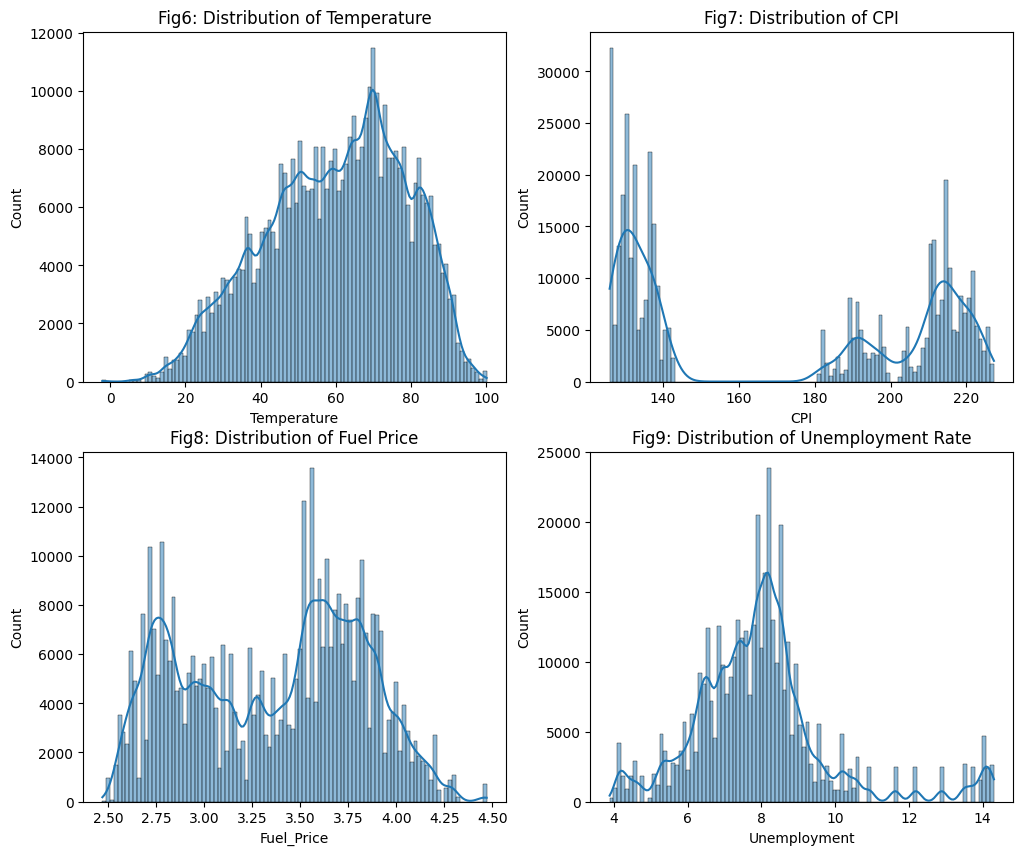

In [308]:
# check the distribution of Temperature, CPI, Fuel_Price, Unemployment
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df['Temperature'], bins=100, ax=axes[0, 0], kde=True);
axes[0, 0].set_title('Fig6: Distribution of Temperature');

sns.histplot(df['CPI'], bins=100, ax=axes[0, 1], kde=True);
axes[0, 1].set_title('Fig7: Distribution of CPI');

sns.histplot(df['Fuel_Price'], bins=100, ax=axes[1, 0], kde=True);
axes[1, 0].set_title('Fig8: Distribution of Fuel Price');

sns.histplot(df['Unemployment'], bins=100, ax=axes[1, 1], kde=True);
axes[1, 1].set_title('Fig9: Distribution of Unemployment Rate');




- Temperature has a somewhat normal distribution, slightly skewed to the left, indicating a temperate environment.
- Fuel_Price and CPI have bimodal distributions. Further investigation is required to understand why.
- Unemployment has strong right tail of extreme values.

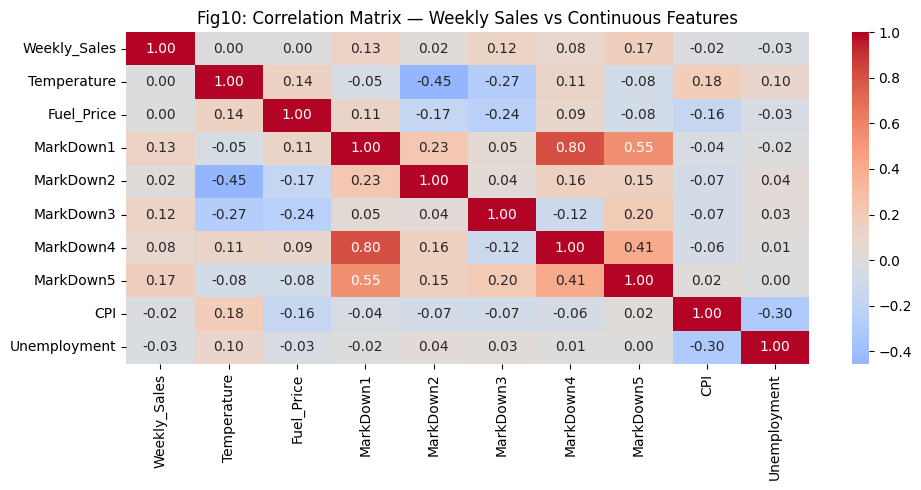

In [309]:
# check correlation between various features and Weekly_Sales
corr = df[['Weekly_Sales', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment']].corr()
plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Fig10: Correlation Matrix — Weekly Sales vs Continuous Features')
plt.tight_layout()
plt.show()

Conclusions:
- CPI, Unemployment, Fuel_Price, Temperature have almost no correlation with Sales, can be ignored
- MarkDown5 seems to be the most effective at increasing Sales, followed my MD 1 and 3, MD 4 and 2 are not very efficient.
- Some of the MarkDowns are highly correlated with each other: 
    - MD 1 with both 4 and 5
    - MD 4 and 5
- CPI is inversly correlated with Unemployment, as expected
- Curiously, Temperature has a strong negative correlation with MarkDown 2

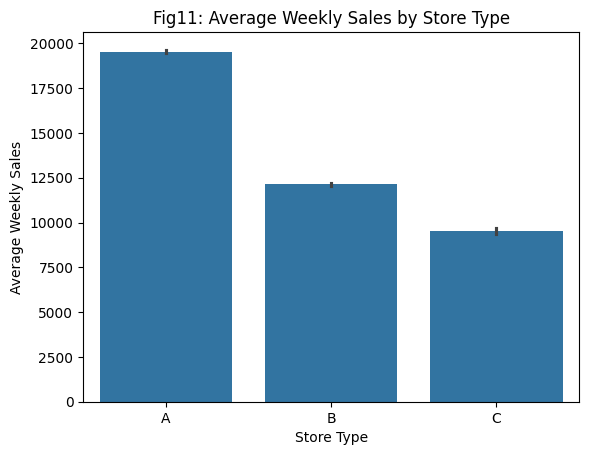

In [310]:
# barplot of store types and sales
fig = sns.barplot(data=df, x='Type', y='Weekly_Sales', errorbar=('ci', 95));
fig.set_title('Fig11: Average Weekly Sales by Store Type')
fig.set_xlabel('Store Type')
fig.set_ylabel('Average Weekly Sales')
plt.show()

- The feature 'Type' seems to refer, or at least be highly related, to the sales performance of the stores.

## Trend Analysis

In [311]:
# investigate overall weekly sales trend
weekly = df.groupby('Date', as_index=False)['Weekly_Sales'].sum()
fig = px.line(
    weekly,
    x='Date',
    y='Weekly_Sales',
    title='Fig12: Overall Weekly Sales Trend (Interactive)',
    labels={'Weekly_Sales': 'Total Weekly Sales', 'Date': 'Week'}
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()

This timeline shows the following:
- The expected massive spikes around Thanksgiving/Black Friday (27-28 Nov) and Christmas.
- Labor Day (7 Sept) no spike, but seems to be followed by a period of very low sales.
- Super Bowl (8 Feb) small spikes, most likely signifying the bounce back from the post-Christmas shopping break.
- In most cases, non-holiday spikes seem to occur on the first week of each month, likely due to the recent payday.


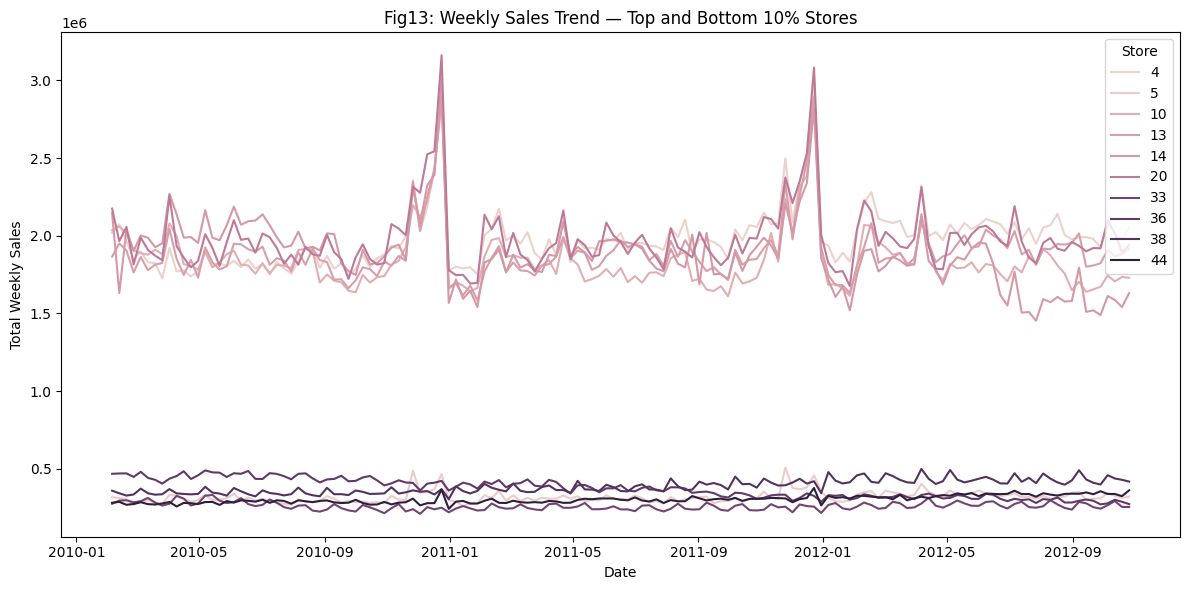

In [312]:
# investigate the sales performance of top and bottom 10% stores
store_totals = df.groupby('Store')['Weekly_Sales'].sum()
top_cutoff = store_totals.quantile(0.9)
bottom_cutoff = store_totals.quantile(0.1)
selected_stores = store_totals[(store_totals >= top_cutoff) | (store_totals <= bottom_cutoff)].index

filtered = df[df['Store'].isin(selected_stores)]
store_trend = filtered.groupby(['Date', 'Store'], as_index=False)['Weekly_Sales'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=store_trend, x='Date', y='Weekly_Sales', hue='Store', legend='full')
plt.title('Fig13: Weekly Sales Trend — Top and Bottom 10% Stores')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.tight_layout()
plt.show()

Comparison between top stores and bottom stores reveals:
- Major difference is the variability: top sellers have big ups and downs, whilst bottom seller have a very flat line.


## Comparative Analysis

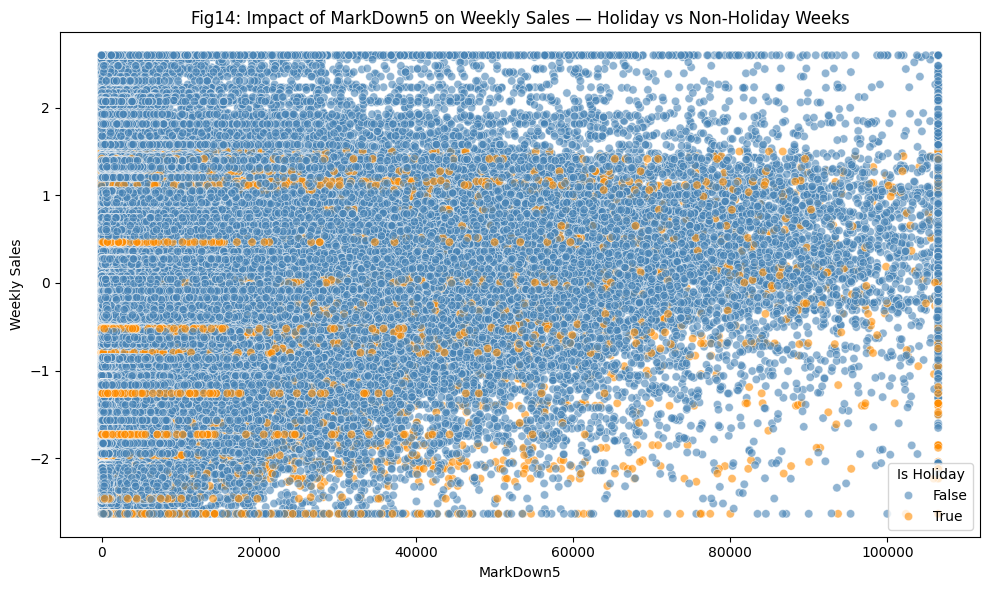

In [313]:
# investigate the impact of MarkDown5 on Weekly_Sales, during Holidays vs non-Holidays
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    y='MarkDown5',
    x='Weekly_Sales',
    hue='Holiday',
    palette={False:'steelblue', True:'darkorange'},
    alpha=0.6)

plt.title('Fig14: Impact of MarkDown5 on Weekly Sales — Holiday vs Non-Holiday Weeks')
plt.xlabel('MarkDown5')
plt.ylabel('Weekly Sales')
plt.legend(title='Is Holiday')
plt.tight_layout()
plt.show()

MarkDown5 has the highest correlation to Weekly_Sales, though at 0.17 it is a modest positive one. Unfortunately, there is no obvious trend visible here which would explain how MarkDown5 is affecting sales and whether its impact is affected by there being a Holiday or not.